# Análisis Estadístico del Dengue en la Provincia de Loja

###Autor: Noelia  Bustan



# Introducción
###Este estudio aplica pruebas de hipótesis y ANOVA sobre los registros de dengue de la provincia de Loja.

# Objetivos
- Filtrar Loja.
- Aplicar prueba t.
- Aplicar ANOVA y Tukey.

In [ ]:
import os

os.listdir()

['.config', 'Datos_Dengue_MSP_Ene2021_Ago2025(2) (1).xlsx', 'sample_data']

In [11]:
import pandas as pd

df = pd.read_excel(
    "Datos_Dengue_MSP_Ene2021_Ago2025(2) (1).xlsx",
    engine="openpyxl"
)

In [12]:
# Importación
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Cargar archivo
archivo='Datos_Dengue_MSP_Ene2021_Ago2025(2) (1).xlsx'
df=pd.read_excel(archivo)

# Limpieza
df.columns=df.columns.str.strip()
df['Provincia']=df['Provincia'].astype(str).str.upper().str.strip()
df['Canton']=df['Canton'].astype(str).str.strip()
df['Total']=pd.to_numeric(df['Total'],errors='coerce')
df=df.dropna(subset=['Total'])

# Filtrar Loja
loja=df[df['Provincia']=='LOJA'].copy()
print(loja.head())
print(loja.shape)


       Año  Semana Institución                       Unidad operativa  \
216   2021       3         MSP                         001055-CASANGA   
303   2021       4         MSP                      001058-GUACHANAMA   
662   2021       7         MSP  002853-UNIDAD ANIDADA HB DE CATACOCHA   
727   2021       8         MSP               001137-ZAPOTILLO - 24 HD   
1192  2021      12         MSP                          001020-LUCERO   

     Unicodigo    Zona                   Distrito Cod_Provincia Provincia  \
216    '001055  ZONA 7                     PALTAS           '11      LOJA   
303    '001058  ZONA 7                     PALTAS           '11      LOJA   
662    '002853  ZONA 7                     PALTAS           '11      LOJA   
727    '001137  ZONA 7                  ZAPOTILLO           '11      LOJA   
1192   '001020  ZONA 7  CALVAS,GONZANAMA,QUILANGA           '11      LOJA   

     Cod_Canton  ... 15-19 M 20-49 H 20-49 M 50-64 H  50-64 M  65+ H  65+ M  \
216       '1109  ..

# Prueba de hipótesis

\[
H_0:\mu=1
\]

\[
H_1:\mu>1
\]

\[
\alpha=0.05
\]


In [13]:
casos=loja['Total']
t,p=stats.ttest_1samp(casos,1)
p=p/2 if t>0 else 1-p/2
print(t,p)
print('Se rechaza H0' if p<0.05 else 'No se rechaza H0')


11.872063028294361 4.92697492417937e-30
Se rechaza H0


In [14]:
top=loja['Canton'].value_counts().head(6).index
datos=loja[loja['Canton'].isin(top)]
modelo=ols('Total ~ C(Canton)',data=datos).fit()
print(sm.stats.anova_lm(modelo,typ=2))
tukey=pairwise_tukeyhsd(datos['Total'],datos['Canton'])
print(tukey)


                 sum_sq     df          F        PR(>F)
C(Canton)   4203.405937    5.0  25.557319  1.719368e-23
Residual   20492.931106  623.0        NaN           NaN
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1    group2  meandiff p-adj   lower   upper  reject
---------------------------------------------------------
CATAMAYO      LOJA  -5.8717    0.0 -7.8419 -3.9015   True
CATAMAYO    MACARA  -0.7884 0.9013 -2.9383  1.3616  False
CATAMAYO    PALTAS  -5.9173    0.0 -8.6171 -3.2175   True
CATAMAYO    PINDAL  -5.7602    0.0 -8.7948 -2.7256   True
CATAMAYO ZAPOTILLO  -5.3927    0.0 -7.6343 -3.1511   True
    LOJA    MACARA   5.0834    0.0  3.2056  6.9611   True
    LOJA    PALTAS  -0.0456    1.0 -2.5341  2.4429  False
    LOJA    PINDAL   0.1115    1.0 -2.7367  2.9598  False
    LOJA ZAPOTILLO    0.479  0.983 -1.5031   2.461  False
  MACARA    PALTAS   -5.129    0.0 -7.7621 -2.4959   True
  MACARA    PINDAL  -4.9718    0.0 -7.9473 -1.9964   True
  MACARA ZAPOTILLO  

<Figure size 1000x500 with 0 Axes>

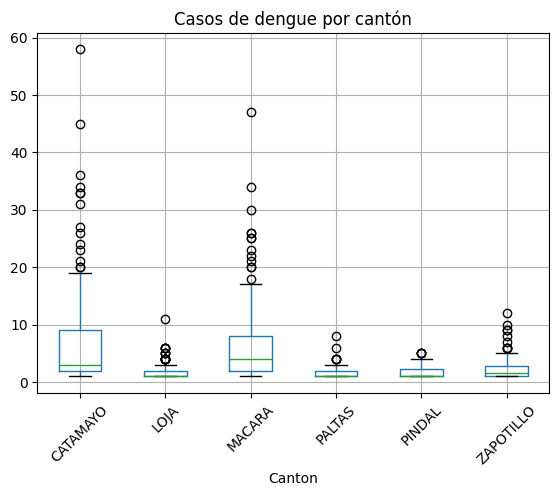

In [15]:
plt.figure(figsize=(10,5))
datos.boxplot(column='Total',by='Canton',rot=45)
plt.suptitle('')
plt.title('Casos de dengue por cantón')
plt.show()


#Conclusiones
###1. El dengue es una amenaza activa y significativa en la provincia de Loja: La prueba estadística realizada demostró, con una alta certeza, que el promedio de casos registrados es claramente mayor a 1. Esto significa que el dengue no es un problema aislado o de un solo caso en la región, sino que existe un volumen constante y preocupante de personas afectadas que requiere atención.

###2. Los cantones de Loja, Paltas, Pindal y Zapotillo son las zonas más críticas: Al comparar los cantones entre sí (prueba de Tukey), se descubrió que los cantones de Loja, Paltas, Pindal y Zapotillo tienen un comportamiento similar entre ellos, pero registran una cantidad de casos significativamente mayor en comparación con Catamayo y Macará.

###3. Catamayo y Macará presentan una menor incidencia: En contraste con las zonas más afectadas, los cantones de Catamayo y Macará no mostraron diferencias importantes entre sí y se mantienen como los lugares con menor promedio de casos reportados dentro de los cantones analizados.